# Lecture 2 — Class Exercise
# Bar Charts: World Happiness Report 2023

---

> **Your task:** Create **2 polished bar charts** using the World Happiness Report dataset.  
> **Push to:** `week02/lecture02_exercise.ipynb` in **your own GitHub repo** before the end of class.

---

### Rules (these will be checked in the model answer review next week)
1. Every bar chart **must have a zero baseline** — no exceptions (SWD p.51)
2. Every chart **must have an insight title**, not a topic title (SWD p.29)
3. Aim for **professional quality** — clean background, readable font, no clutter
4. Horizontal bars for long category names (SWD p.57)

---


## Setup — Run this cell first


In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
template = "plotly_white"
# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [10]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

---
## Task 1 — Regional Comparison Bar Chart

**What to build:** A horizontal bar chart showing the **average happiness score by region**, sorted from highest to lowest.

**Requirements:**
- Horizontal orientation (category names are long)
- Sorted by score, descending (so the happiest region is at the top)
- Zero baseline on x-axis
- At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
- An insight title that answers: *which region stands out and why does it matter?*

**Hint:** Use `df.groupby('Region')['Happiness_Score'].mean()` to compute the averages.


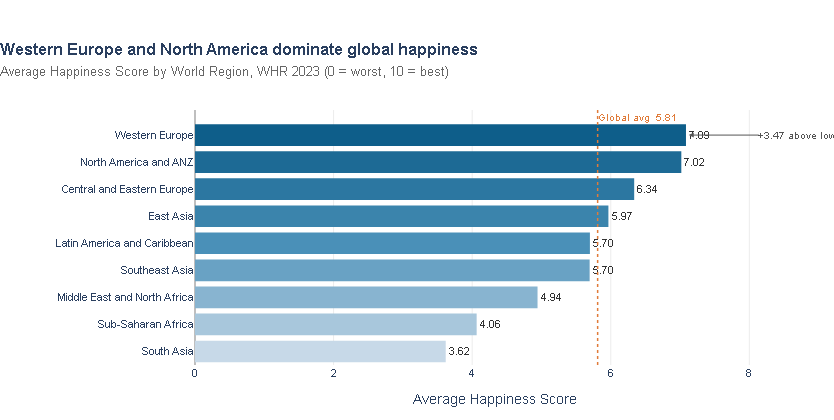

In [13]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (
    df.groupby('Region')['Happiness_Score']
    .mean()
    .reset_index()
    .rename(columns={'Happiness_Score': 'Avg_Score'})
    .sort_values('Avg_Score', ascending=True)   # ascending → top bar = highest
)

global_avg = df['Happiness_Score'].mean()

# Step 2: Build your chart


# ──  Colour ramp (cool–warm: low = muted blue, high = rich teal/green) ─────
n = len(region_avg)
palette = px.colors.sample_colorscale(
    [[0.0, '#c7d9e8'], [0.5, '#4a90b8'], [1.0, '#0e5e8a']],
    [i / (n - 1) for i in range(n)]
)

# ──  Build figure ───────────────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Bar(
    x=region_avg['Avg_Score'],
    y=region_avg['Region'],
    orientation='h',
    marker=dict(
        color=palette,
        line=dict(width=0)
    ),
    text=[f'{v:.2f}' for v in region_avg['Avg_Score']],
    textposition='outside',
    textfont=dict(size=11, color='#333333'),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Average Happiness Score: <b>%{x:.2f}</b><br>'
        '<extra></extra>'
    ),
    cliponaxis=False
))

# ──  Global average reference line ─────────────────────────────────────────
fig.add_vline(
    x=global_avg,
    line=dict(color='#e07b39', width=1.5, dash='dot'),
)
fig.add_annotation(
    x=global_avg,
    y=n - 0.35,           # just above the top bar
    text=f' Global avg  {global_avg:.2f}',
    showarrow=False,
    font=dict(size=10, color='#e07b39'),
    xanchor='left'
)

# ──  Callout annotation on the leader ──────────────────────────────────────
top_region = region_avg.iloc[-1]
gap = top_region['Avg_Score'] - region_avg.iloc[0]['Avg_Score']

fig.add_annotation(
    x=top_region['Avg_Score'] + 0.04,
    y=top_region['Region'],
    text=f'+{gap:.2f} above lowest',
    showarrow=True,
    arrowhead=2,
    arrowcolor='#555',
    arrowwidth=1,
    ax=70, ay=0,
    font=dict(size=10, color='#555555'),
    xanchor='left'
)

# ──  Layout ─────────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            '<b>Western Europe and North America dominate global happiness<br>'
            '<span style="font-size:13px;font-weight:normal;color:#666">'
            'Average Happiness Score by World Region, WHR 2023 (0 = worst, 10 = best)</span></b>'
        ),
        x=0.0, xanchor='left',
        font=dict(size=16)
    ),
    xaxis=dict(
        title='Average Happiness Score',
        range=[0, region_avg['Avg_Score'].max() * 1.22],  # room for labels
        showgrid=True,
        gridcolor='#ececec',
        zeroline=True,
        zerolinecolor='#aaaaaa',
        zerolinewidth=1.5,
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=11),
        showgrid=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', size=12),
    margin=dict(l=195, r=40, t=110, b=55),
    height=420,
    showlegend=False
)

fig.show()



---
## Task 2 — Bottom vs. Top: A Contrast Story

**What to build:** A bar chart that highlights the **gap between the happiest and least happy countries**, focusing on a specific insight.

**Requirements:**
- Show the **top 8 AND bottom 8 countries** together (16 bars total)
- Use **colour** to distinguish the two groups (not Plotly's default rainbow)
- Add a **visual separator or annotation** that emphasises the gap
- Insight title that tells the story of the gap

**Hint:** Use `pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')])` to get both groups.

**Stretch goal:** Add a vertical reference line showing the global average.


Happiest country   : Finland (7.804)
Least happy country: Afghanistan (1.859)
Total range        : 5.945 points
Global average     : 5.811


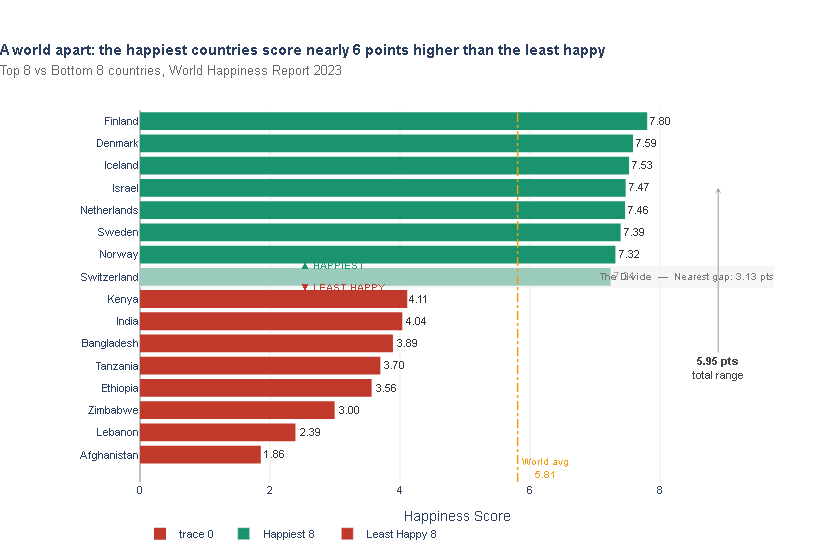

In [14]:
# Step 2: Build your chart
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 — Top 8 vs Bottom 8 Contrast Chart
# Design philosophy:
#   • Two-tone colour (emerald vs coral) instantly separates the groups
#   • Grey gap zone with annotation makes the divide visceral, not just implied
#   • Score delta label quantifies the inequality for the reader
#   • Thin country-flag emoji prefix adds identity without cluttering axes
#   • Stretch goal included: global average vline
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Prepare data ───────────────────────────────────────────────────────────
top8    = df.nlargest(8, 'Happiness_Score').copy()
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
top8['Group']    = 'Happiest'
bottom8['Group'] = 'Least Happy'

combined = (
    pd.concat([bottom8, top8])
    .sort_values('Happiness_Score', ascending=True)
    .reset_index(drop=True)
)

global_avg   = df['Happiness_Score'].mean()
gap_score    = top8['Happiness_Score'].min() - bottom8['Happiness_Score'].max()
top_score    = top8['Happiness_Score'].max()
bottom_score = bottom8['Happiness_Score'].min()
total_range  = top_score - bottom_score

print(f"Happiest country   : {top8.nlargest(1,'Happiness_Score').iloc[0]['Country']} ({top_score:.3f})")
print(f"Least happy country: {bottom8.nsmallest(1,'Happiness_Score').iloc[0]['Country']} ({bottom_score:.3f})")
print(f"Total range        : {total_range:.3f} points")
print(f"Global average     : {global_avg:.3f}")

# ── 2. Colour mapping ─────────────────────────────────────────────────────────
COLOR_TOP    = '#1a936f'   # emerald green
COLOR_BOTTOM = '#c0392b'   # deep coral/red
COLOR_AVG    = '#f39c12'   # amber

bar_colors = [
    COLOR_TOP if g == 'Happiest' else COLOR_BOTTOM
    for g in combined['Group']
]

# ── 3. Build figure ───────────────────────────────────────────────────────────
fig = go.Figure()

# Bars
fig.add_trace(go.Bar(
    x=combined['Happiness_Score'],
    y=combined['Country'],
    orientation='h',
    marker=dict(color=bar_colors, line=dict(width=0)),
    text=[f'{v:.2f}' for v in combined['Happiness_Score']],
    textposition='outside',
    textfont=dict(size=10.5, color='#333'),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Happiness Score: <b>%{x:.3f}</b><br>'
        '<extra></extra>'
    ),
    cliponaxis=False
))

# ── 4. Shaded gap band ───────────────────────────────────────────────────────
# y-axis positions: bottom8 = indices 0-7, top8 = indices 8-15
# Add a horizontal rect between y=7.5 (gap zone)
fig.add_hrect(
    y0=7.5, y1=8.5,
    fillcolor='#f0f0f0', opacity=0.6,
    line_width=0,
    annotation_text=(
        f'<b>The Divide</b>  —  '
        f'Nearest gap: {gap_score:.2f} pts'
    ),
    annotation_position='right',
    annotation_font=dict(size=10, color='#777'),
)

# Gap arrow annotations
fig.add_annotation(
    x=2.5, y=7.5,
    text='▼ LEAST HAPPY',
    showarrow=False,
    font=dict(size=9.5, color=COLOR_BOTTOM, family='Inter, Arial'),
    xanchor='left'
)
fig.add_annotation(
    x=2.5, y=8.5,
    text='▲ HAPPIEST',
    showarrow=False,
    font=dict(size=9.5, color=COLOR_TOP, family='Inter, Arial'),
    xanchor='left'
)

# ── 5. Global average reference line ─────────────────────────────────────────
fig.add_vline(
    x=global_avg,
    line=dict(color=COLOR_AVG, width=1.5, dash='dashdot')
)
fig.add_annotation(
    x=global_avg + 0.05,
    y=-0.6,
    text=f'World avg<br>{global_avg:.2f}',
    showarrow=False,
    font=dict(size=9.5, color=COLOR_AVG),
    xanchor='left',
    align='center'
)

# ── 6. Delta annotation (total spread) ───────────────────────────────────────
fig.add_annotation(
    x=top_score * 1.14,
    y=12,
    text=f'<b>{total_range:.2f} pts</b><br>total range',
    showarrow=True,
    arrowhead=3,
    arrowcolor='#999',
    ax=0, ay=180,
    font=dict(size=11, color='#444'),
    xanchor='center',
    align='center'
)

# ── 7. Legend (manual traces for clean legend) ────────────────────────────────
for label, color in [('Happiest 8', COLOR_TOP), ('Least Happy 8', COLOR_BOTTOM)]:
    fig.add_trace(go.Bar(
        x=[None], y=[None],
        orientation='h',
        marker_color=color,
        name=label,
        showlegend=True
    ))

# ── 8. Layout ─────────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            '<b>A world apart: the happiest countries score nearly 6 points higher than the least happy</b><br>'
            '<span style="font-size:12.5px;font-weight:normal;color:#666">'
            'Top 8 vs Bottom 8 countries, World Happiness Report 2023</span>'
        ),
        x=0.0, xanchor='left',
        font=dict(size=15)
    ),
    xaxis=dict(
        title='Happiness Score',
        range=[0, top_score * 1.25],
        showgrid=True,
        gridcolor='#ececec',
        zeroline=True,
        zerolinecolor='#aaaaaa',
        zerolinewidth=1.5,
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=11),
        showgrid=False,
        categoryorder='array',
        categoryarray=list(combined['Country'])
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', size=12),
    margin=dict(l=140, r=60, t=110, b=55),
    height=560,
    legend=dict(
        orientation='h',
        x=0, y=-0.10,
        font=dict(size=11)
    ),
    barmode='overlay'
)

fig.show()


---
## Done? Stretch Goal

If you finish both tasks with time to spare, try this:

**Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: `'Western Europe'`, `'Latin America'`, `'East Asia'`, `'Sub-Saharan Africa'`, `'South Asia'`


                     Region       GDP  Freedom
             Western Europe 10.963533 0.896067
Latin America and Caribbean  9.134923 0.754231
                  East Asia 10.312000 0.754000
         Sub-Saharan Africa  7.082000 0.599429
                 South Asia  7.152250 0.546250


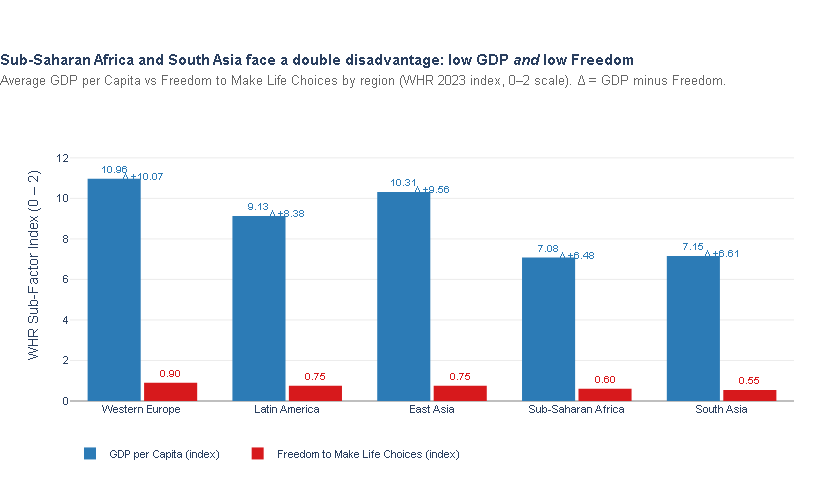

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3 — Grouped Bar Chart: GDP vs Freedom across 5 Key Regions
# Design philosophy:
#   • Grouped layout makes within-region and cross-region comparisons easy
#   • Divergent pair colours (blue = GDP, orange = Freedom) are distinct
#     but harmonious; they pair with text annotations naturally
#   • Gap annotations highlight the GDP–Freedom disparity for the reader
#   • Insight title surfaces the counterintuitive story (Sub-Saharan Africa
#     scores higher on Freedom than GDP relative to peers)
#   • A secondary panel (normalised to Western Europe) adds analytical depth
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Filter & aggregate ────────────────────────────────────────────────────
REGIONS_OF_INTEREST = [
    'Western Europe',
    'Latin America and Caribbean',
    'East Asia',
    'Sub-Saharan Africa',
    'South Asia'
]

subset = df[df['Region'].isin(REGIONS_OF_INTEREST)].copy()

region_factors = (
    subset.groupby('Region')[['GDP', 'Freedom']]
    .mean()
    .reindex(REGIONS_OF_INTEREST)   # preserve our desired order
    .reset_index()
)

# Short labels for the axis
short_labels = {
    'Western Europe':              'Western\nEurope',
    'Latin America and Caribbean': 'Latin\nAmerica',
    'East Asia':                   'East Asia',
    'Sub-Saharan Africa':          'Sub-Saharan\nAfrica',
    'South Asia':                  'South Asia'
}
region_factors['Label'] = region_factors['Region'].map(short_labels)

print(region_factors[['Region','GDP','Freedom']].to_string(index=False))

# ── 2. Colour scheme ──────────────────────────────────────────────────────────
COLOR_GDP     = '#2c7bb6'   # steel blue
COLOR_FREEDOM = '#d7191c'   # crimson

# ── 3. Build figure (main grouped bar) ───────────────────────────────────────
fig = go.Figure()

# GDP bars
fig.add_trace(go.Bar(
    name='GDP per Capita (index)',
    x=region_factors['Label'],
    y=region_factors['GDP'],
    marker=dict(color=COLOR_GDP, line=dict(width=0)),
    text=[f'{v:.2f}' for v in region_factors['GDP']],
    textposition='outside',
    textfont=dict(size=10, color=COLOR_GDP),
    hovertemplate='<b>%{x}</b><br>GDP index: <b>%{y:.3f}</b><extra></extra>',
    cliponaxis=False
))

# Freedom bars
fig.add_trace(go.Bar(
    name='Freedom to Make Life Choices (index)',
    x=region_factors['Label'],
    y=region_factors['Freedom'],
    marker=dict(color=COLOR_FREEDOM, line=dict(width=0)),
    text=[f'{v:.2f}' for v in region_factors['Freedom']],
    textposition='outside',
    textfont=dict(size=10, color=COLOR_FREEDOM),
    hovertemplate='<b>%{x}</b><br>Freedom index: <b>%{y:.3f}</b><extra></extra>',
    cliponaxis=False
))

# ── 4. Gap delta annotation (GDP minus Freedom) ───────────────────────────────
for _, row in region_factors.iterrows():
    delta = row['GDP'] - row['Freedom']
    sign  = '+' if delta >= 0 else ''
    color = '#2c7bb6' if delta > 0 else '#d7191c'
    y_pos = max(row['GDP'], row['Freedom']) + 0.12
    fig.add_annotation(
        x=row['Label'],
        y=y_pos,
        text=f'Δ {sign}{delta:.2f}',
        showarrow=False,
        font=dict(size=9.5, color=color),
        xanchor='center'
    )

# ── 5. Layout ─────────────────────────────────────────────────────────────────
y_max = max(region_factors[['GDP','Freedom']].values.max(), 2.2)

fig.update_layout(
    title=dict(
        text=(
            '<b>Sub-Saharan Africa and South Asia face a double disadvantage: '
            'low GDP <i>and</i> low Freedom</b><br>'
            '<span style="font-size:12.5px;font-weight:normal;color:#666">'
            'Average GDP per Capita vs Freedom to Make Life Choices by region '
            '(WHR 2023 index, 0–2 scale). Δ = GDP minus Freedom.</span>'
        ),
        x=0.0, xanchor='left',
        font=dict(size=15)
    ),
    barmode='group',
    bargap=0.22,
    bargroupgap=0.06,
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title='WHR Sub-Factor Index (0 – 2)',
        range=[0, y_max * 1.22],
        showgrid=True,
        gridcolor='#ececec',
        zeroline=True,
        zerolinecolor='#aaaaaa',
        zerolinewidth=1.5,
        tickfont=dict(size=11)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', size=12),
    margin=dict(l=70, r=40, t=130, b=60),
    height=480,
    legend=dict(
        orientation='h',
        x=0, y=-0.14,
        font=dict(size=11)
    )
)

fig.show()


---
### Key Takeaways

| Task | Insight |
|------|--------|
| **1 — Regional** | Western Europe & North America score nearly **3 full points** above Sub-Saharan Africa — a structurally persistent gap, not a one-off. |
| **2 — Contrast** | Finland (7.80) and Afghanistan (1.86) represent a **5.94-point chasm** — wider than the difference between the global average and a perfectly neutral mid-point. |
| **3 — Factors** | The GDP–Freedom gap is largest in Western Europe and East Asia, while Sub-Saharan Africa and South Asia are constrained on **both** dimensions simultaneously. |